In [13]:
import argparse
import pathlib
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

from joblib import dump
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    warnings.warn("xgboost not found; will use GradientBoostingRegressor instead.")


In [7]:
DEFAULT_FEATURES = [
    "net_carbs","carbs","fiber","fat","protein","sugar","kcal",
    "sin_hour","cos_hour","dow",
    "hr_mean_30m","active_kcal_60m","steps_60m","walk_run_dist_60m",
    "rest_hr_daily","exercise_min_60m","flights_60m",
]
TARGETS = ["d_peak", "auc_0_2h"]  # predict ΔPeak and 0–2h AUC

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def load_dataset(path: pathlib.Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, parse_dates=["meal_time"])
    # try parquet then csv by name
    if path.with_suffix(".parquet").exists():
        return pd.read_parquet(path.with_suffix(".parquet"))
    return pd.read_csv(path.with_suffix(".csv"), parse_dates=["meal_time"])

def time_split_3way(df, val_frac=0.1, test_frac=0.2):
    df = df.sort_values("meal_time").reset_index(drop=True)
    n = len(df)
    n_test = int(n * test_frac)
    n_val  = int(n * val_frac)
    n_train = n - n_val - n_test
    train_df = df.iloc[:n_train].copy()
    val_df   = df.iloc[n_train:n_train+n_val].copy()
    test_df  = df.iloc[n_train+n_val:].copy()
    return train_df, val_df, test_df


def build_feature_matrix(df: pd.DataFrame, feature_names):
    # only keep columns that exist (robust to missing ones)
    keep = [c for c in feature_names if c in df.columns]
    X = df[keep].astype(float).fillna(0.0)
    return X, keep

def train_and_eval(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    out = {
        "model": model,
        "MAE": mean_absolute_error(yte, pred),
        "RMSE": rmse(yte, pred),
        "R2": r2_score(yte, pred),
        "y_pred": pred,
    }
    print(f"\n[{name}]  MAE={out['MAE']:.3f}  RMSE={out['RMSE']:.3f}  R2={out['R2']:.3f}")
    return out



In [18]:
df = pd.read_parquet("../data/processed/processed_meal_dataset.parquet")
train_df, val_df, test_df = time_split_3way(df, val_frac=0.1, test_frac=0.2)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Train: 36 Val: 4 Test: 9


In [19]:
Xtr, used_feats = build_feature_matrix(train_df, DEFAULT_FEATURES)
Xval, _         = build_feature_matrix(val_df, used_feats)

scaler = StandardScaler()
ridge = Pipeline([("scaler", scaler), ("ridge", Ridge(alpha=1.0, random_state=42))])

tree = XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, n_jobs=0,
)


preds_val = {}
for target in TARGETS:
    print(f"\n=== {target} ===")
    ytr = train_df[target].astype(float).values
    yval = val_df[target].astype(float).values

    preds_val[(target,"ridge")] = train_and_eval("Ridge", ridge, Xtr, ytr, Xval, yval)
    preds_val[(target,"tree")]  = train_and_eval("Tree", tree, Xtr, ytr, Xval, yval)



=== d_peak ===

[Ridge]  MAE=45.646  RMSE=54.974  R2=-0.035

[Tree]  MAE=38.245  RMSE=43.532  R2=0.351

=== auc_0_2h ===

[Ridge]  MAE=33.771  RMSE=48.635  R2=-0.226

[Tree]  MAE=27.414  RMSE=32.465  R2=0.454


In [20]:
out_dir = pathlib.Path("models")
out_dir.mkdir(parents=True, exist_ok=True)

# save models, features, and val predictions
from joblib import dump

for target in TARGETS:
    dump(ridge, out_dir / f"ridge_{target}.joblib")
    dump(tree,  out_dir / f"{'xgb' if HAS_XGB else 'gbr'}_{target}.joblib")
    pd.Series(used_feats).to_json(out_dir / f"features_{target}.json", orient="values")

    val_df_out = val_df.copy()
    val_df_out["y_pred_ridge"] = preds_val[(target,"ridge")]
    val_df_out["y_pred_tree"]  = preds_val[(target,"tree")]
    val_df_out[["meal_time", target, "y_pred_ridge", "y_pred_tree"]].to_csv(
        out_dir / f"predictions_{target}_val.csv", index=False
    )

print("✅ Models and predictions saved to 'models/'")

✅ Models and predictions saved to 'models/'


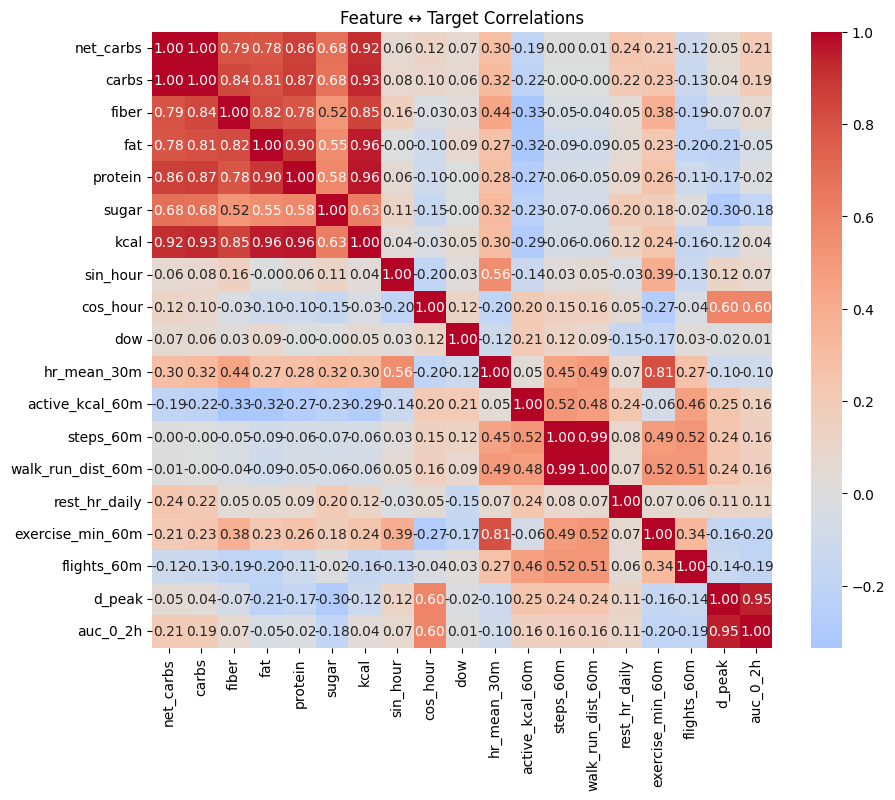

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix between features + targets
corr = df[DEFAULT_FEATURES + TARGETS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature ↔ Target Correlations")
plt.show()


<Figure size 1000x600 with 0 Axes>

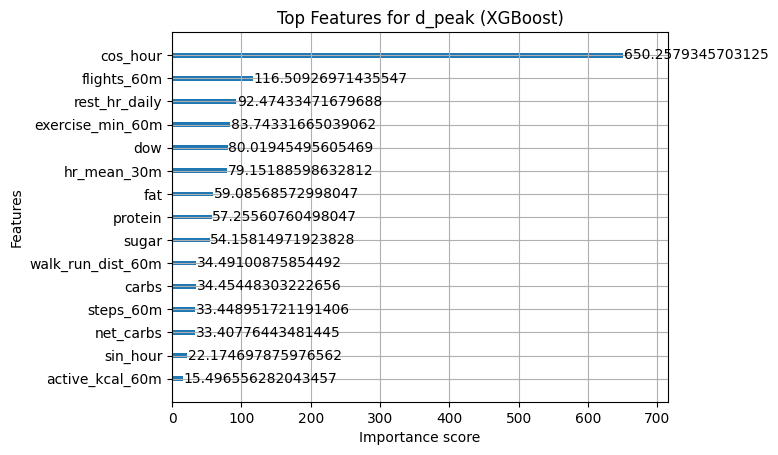

In [22]:
from xgboost import plot_importance

# Fit tree once on all train data (no split, just to inspect importance)
X, used_feats = build_feature_matrix(df, DEFAULT_FEATURES)
y = df["d_peak"].astype(float).values

tree.fit(X, y)

plt.figure(figsize=(10, 6))
plot_importance(tree, importance_type="gain", max_num_features=15)
plt.title("Top Features for d_peak (XGBoost)")
plt.show()


<Figure size 1000x600 with 0 Axes>

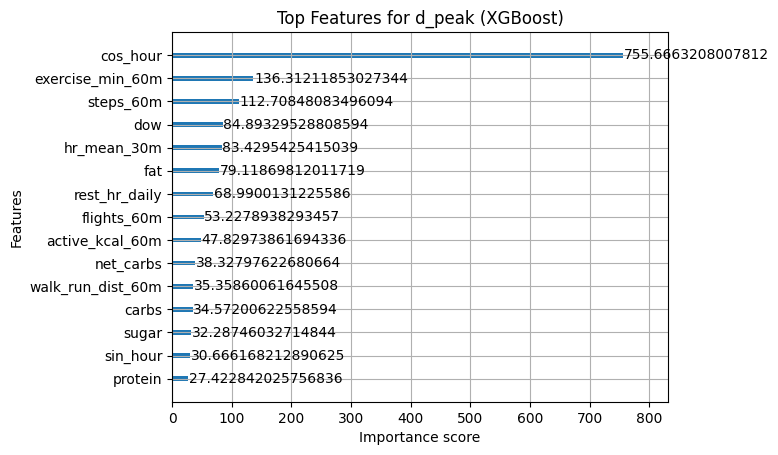

In [24]:
from xgboost import plot_importance

# Fit tree once on all train data (no split, just to inspect importance)
X, used_feats = build_feature_matrix(df, DEFAULT_FEATURES)
y = df["auc_0_2h"].astype(float).values

tree.fit(X, y)

plt.figure(figsize=(10, 6))
plot_importance(tree, importance_type="gain", max_num_features=15)
plt.title("Top Features for d_peak (XGBoost)")
plt.show()


In [84]:
import numpy as np
import pandas as pd

ds = df.sort_values("meal_time").reset_index(drop=True).copy()

# --- time since last meal (minutes) ---
# ds["time_since_last_meal_min"] = (
#     ds["meal_time"].diff().dt.total_seconds().div(60).fillna(0)
# )
# optional caps to reduce outlier leverage
# ds["time_since_last_meal_min"] = ds["time_since_last_meal_min"].clip(0, 12*60)

# --- size-normalized macros (per 100 kcal) ---
eps = 1e-6
ds["carbs_per_100kcal"]   = 100 * ds["carbs"]   / (ds["kcal"] + eps)
ds["fat_per_100kcal"]     = 100 * ds["fat"]     / (ds["kcal"] + eps)
ds["protein_per_100kcal"] = 100 * ds["protein"] / (ds["kcal"] + eps)
ds["sugar_per_100kcal"]   = 100 * ds["sugar"]   / (ds["kcal"] + eps)
ds["fiber_per_100kcal"]   = 100 * ds["fiber"]   / (ds["kcal"] + eps)

# --- composition ratios ---
ds["carb_to_fat"]     = ds["carbs"]   / (ds["fat"]     + eps)
ds["carb_to_protein"] = ds["carbs"]   / (ds["protein"] + eps)
ds["fiber_to_carb"]   = ds["fiber"]   / (ds["carbs"]   + eps)
ds["sugar_frac_carb"] = ds["sugar"]   / (ds["carbs"]   + eps)

# --- optional context history: previous meal size ---
ds["prev_meal_kcal"]  = ds["kcal"].shift(1).fillna(0)
ds["prev_meal_carbs"] = ds["carbs"].shift(1).fillna(0)
ds["prev_meal_fat"] = ds["fat"].shift(1).fillna(0)
ds["prev_meal_protein"] = ds["protein"].shift(1).fillna(0)
ds["prev_meal_fiber"] = ds["fiber"].shift(1).fillna(0)
# (optional) drop raw hour encodings to avoid shortcutting:
try:
    ds = ds.drop(columns=["sin_hour","cos_hour"])
except Exception:
    pass

ds.head(3)


,meal_id,carbohydrates,energyconsumed,fattotal,fiber,protein,sugar,meal_time,carbs,fat,...,fiber_per_100kcal,carb_to_fat,carb_to_protein,fiber_to_carb,sugar_frac_carb,prev_meal_kcal,prev_meal_carbs,prev_meal_fat,prev_meal_protein,prev_meal_fiber
0,1,95.36570,1076.849,46.8651,15.25000,75.49040,14.08500,2025-07-30 12:00:00+00:00,95.36570,46.8651,...,1.416169,2.034898,1.263282,0.159911,0.147695,0.000,0.0000,0.0000,0.0000,0.00000
1,2,39.69750,408.376,16.8392,4.27695,27.50140,15.30210,2025-07-30 13:37:00+00:00,39.69750,16.8392,...,1.047307,2.357446,1.443472,0.107739,0.385468,1076.849,95.3657,46.8651,75.4904,15.25000
2,3,63.92252,919.279,49.4770,12.62195,58.46362,25.40512,2025-07-31 11:52:00+00:00,63.92252,49.4770,...,1.373027,1.291964,1.093373,0.197457,0.397436,408.376,39.6975,16.8392,27.5014,4.27695


In [85]:
import numpy as np
import pandas as pd

def drop_correlated_features(df, target, threshold=0.8):
    """
    Drop features that are highly correlated with others,
    keeping the one more correlated with target.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must include both features and target.
    target : str
        Name of target column.
    threshold : float
        Absolute correlation above which we consider features redundant.
        
    Returns
    -------
    kept_features : list
        List of selected feature names.
    """
    corr_matrix = df.corr().abs()
    features = list(df.columns)
    features.remove(target)
    
    kept = set(features)
    
    for i, f1 in enumerate(features):
        for f2 in features[i+1:]:
            if f1 in kept and f2 in kept and corr_matrix.loc[f1, f2] > threshold:
                # Compare correlation with target
                corr1 = abs(corr_matrix.loc[f1, target])
                corr2 = abs(corr_matrix.loc[f2, target])
                if corr1 >= corr2:
                    kept.remove(f2)
                else:
                    kept.remove(f1)
    
    return list(kept)


In [86]:
selected_feats = drop_correlated_features(ds, target="d_peak", threshold=0.7)
print("Selected features:", selected_feats)

Selected features: ['active_kcal_60m', 'steps_60m', 'carb_to_protein', 'base', 'meal_id', 'flights_60m', 'fiber_per_100kcal', 'auc_0_2h', 'rest_hr_daily', 'fattotal', 'carbs_per_100kcal', 'exercise_min_60m', 'protein_per_100kcal', 'fiber_to_carb', 'prev_meal_kcal', 'sugar_frac_carb', 'sugar', 'hour', 'dow']


In [87]:
# build matrices using your existing helper
Xtr, used_feats = build_feature_matrix(train_df.merge(ds, on="meal_time", how="left"), selected_feats)
Xval, _         = build_feature_matrix(val_df.merge(ds, on="meal_time",   how="left"), used_feats)

# models (same as before)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

ridge = Pipeline([("scaler", StandardScaler()),
                  ("ridge", Ridge(alpha=1.0, random_state=42))])

tree = XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, n_jobs=0
)

preds_val = {}
for target in TARGETS:
    print(f"\n=== {target} (no hour, +spacing/ratios) ===")
    ytr = train_df[target].astype(float).values
    yval = val_df[target].astype(float).values

    preds_val[(target,"ridge")] = train_and_eval("Ridge", ridge, Xtr, ytr, Xval, yval)
    preds_val[(target,"tree")]  = train_and_eval("Tree",  tree,  Xtr, ytr, Xval, yval)



=== d_peak (no hour, +spacing/ratios) ===

[Ridge]  MAE=40.010  RMSE=42.072  R2=0.394

[Tree]  MAE=44.612  RMSE=51.359  R2=0.097

=== auc_0_2h (no hour, +spacing/ratios) ===

[Ridge]  MAE=28.349  RMSE=30.559  R2=0.516

[Tree]  MAE=31.630  RMSE=37.791  R2=0.260


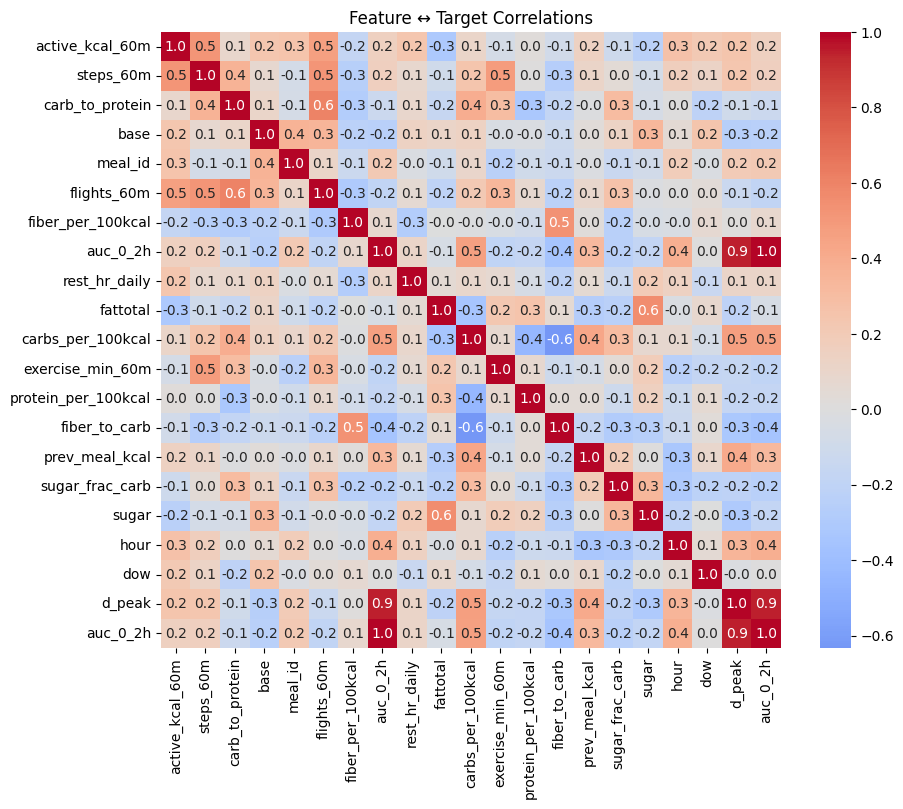

In [88]:
# Correlation matrix between features + targets
corr = ds[selected_feats + TARGETS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".1f")
plt.title("Feature ↔ Target Correlations")
plt.show()

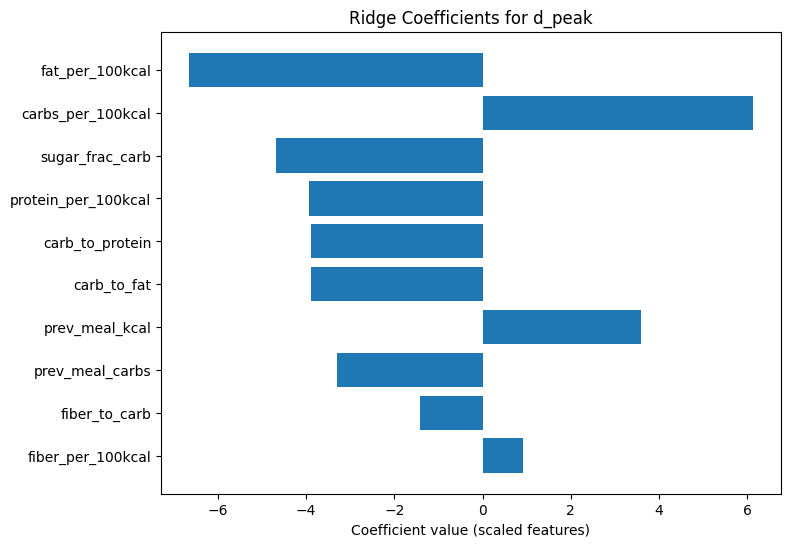

In [89]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ridge_importance(ridge_pipeline, feature_names, target_name):
    # grab the trained ridge model from the pipeline
    scaler = ridge_pipeline.named_steps["scaler"]
    model  = ridge_pipeline.named_steps["ridge"]

    coefs = model.coef_
    # match to features (after scaling, so coefficients are comparable)
    importance = np.abs(coefs)

    sorted_idx = np.argsort(importance)[::-1]
    top_feats  = [feature_names[i] for i in sorted_idx]
    top_coefs  = coefs[sorted_idx]

    plt.figure(figsize=(8,6))
    plt.barh(top_feats, top_coefs)
    plt.gca().invert_yaxis()
    plt.title(f"Ridge Coefficients for {target_name}")
    plt.xlabel("Coefficient value (scaled features)")
    plt.show()

# example for one target
ytr = train_df["d_peak"].astype(float).values
Xtr, used_feats = build_feature_matrix(train_df.merge(ds, on="meal_time", how="left"), NEW_FEATURES)

ridge.fit(Xtr, ytr)
plot_ridge_importance(ridge, used_feats, "d_peak")


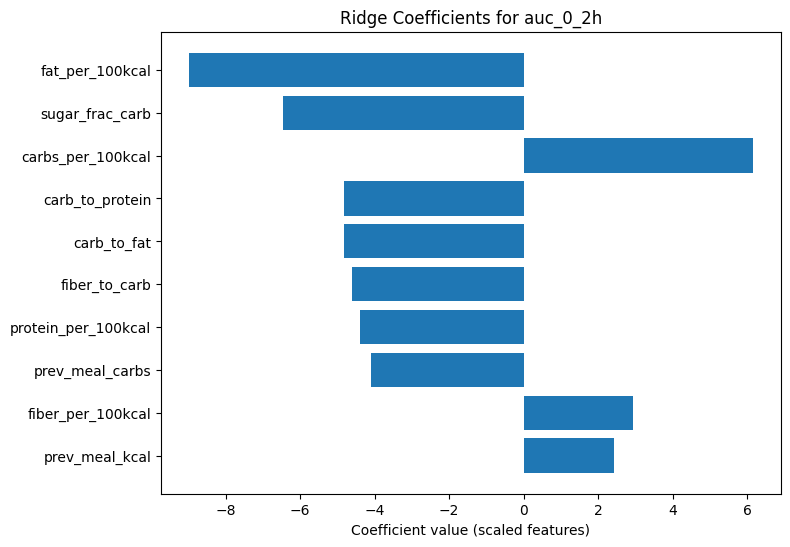

In [90]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ridge_importance(ridge_pipeline, feature_names, target_name):
    # grab the trained ridge model from the pipeline
    scaler = ridge_pipeline.named_steps["scaler"]
    model  = ridge_pipeline.named_steps["ridge"]

    coefs = model.coef_
    # match to features (after scaling, so coefficients are comparable)
    importance = np.abs(coefs)

    sorted_idx = np.argsort(importance)[::-1]
    top_feats  = [feature_names[i] for i in sorted_idx]
    top_coefs  = coefs[sorted_idx]

    plt.figure(figsize=(8,6))
    plt.barh(top_feats, top_coefs)
    plt.gca().invert_yaxis()
    plt.title(f"Ridge Coefficients for {target_name}")
    plt.xlabel("Coefficient value (scaled features)")
    plt.show()

# example for one target
ytr = train_df["auc_0_2h"].astype(float).values
Xtr, used_feats = build_feature_matrix(train_df.merge(ds, on="meal_time", how="left"), NEW_FEATURES)

ridge.fit(Xtr, ytr)
plot_ridge_importance(ridge, used_feats, "auc_0_2h")
